# 🏆 Prosper Loan — Top 3 Model Klasifikasi + Hyperparameter Tuning

**Alur:**
1. Feature Engineering (sama persis dengan notebook asal)
2. Feature Selection (RF Importance, sama persis)
3. Benchmark 3 Model: LightGBM, XGBoost, CatBoost (5-Fold CV)
4. Pilih model terbaik (AUC) → Optuna Tuning
5. Evaluasi final + simpan model

## 0. Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection  import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import OrdinalEncoder, RobustScaler
from sklearn.impute           import SimpleImputer
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier

from imblearn.pipeline      import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


## 1. Load Data & Buat Label Target

In [12]:
# ⚠️ Sesuaikan path file
df = pd.read_csv("C:/Users/ASUS TUF/Documents/ML OPS/PRAKTIKUM/cleaning_prosperloadata.csv")

print(f'Shape dataset  : {df.shape}')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')

# Buat label target
def map_loan_status(status):
    if status in ['Completed', 'Current', 'FinalPaymentInProgress']:
        return 1   # ACC
    else:
        return 0   # REJECT

df['LoanApprovalStatus'] = df['LoanStatus'].apply(map_loan_status)

label_counts = df['LoanApprovalStatus'].value_counts()
print(f'\n  ACC    (1) : {label_counts[1]:,} ({label_counts[1]/len(df):.1%})')
print(f'  REJECT (0) : {label_counts[0]:,} ({label_counts[0]/len(df):.1%})')

Shape dataset  : (6792, 51)
Jumlah baris   : 6,792
Jumlah kolom   : 51

  ACC    (1) : 5,668 (83.5%)
  REJECT (0) : 1,124 (16.5%)


## 2. Feature Engineering
> **Sama persis** dengan notebook asal — tidak ada perubahan

In [13]:
df_fe = df.copy()

# 1. Rasio hutang terhadap kredit yang tersedia
df_fe['debt_to_available_credit'] = (
    df_fe['RevolvingCreditBalance'] /
    (df_fe['AvailableBankcardCredit'] + df_fe['RevolvingCreditBalance'] + 1)
).clip(0, 1)

# 2. Tingkat delinquency sepanjang riwayat kredit
df_fe['delinq_rate'] = (
    df_fe['DelinquenciesLast7Years'] /
    (df_fe['TotalTrades'] + 1)
).clip(0, 1)

# 3. Utilisasi kredit revolving
df_fe['revolving_util'] = (
    df_fe['OpenRevolvingMonthlyPayment'] * 12 /
    (df_fe['StatedMonthlyIncome'] * 12 + 1)
).clip(0, 2)

# 4. Skor gabungan delinquency
df_fe['delinq_composite'] = (
    df_fe['CurrentDelinquencies'] * 3 +
    df_fe['DelinquenciesLast7Years'] +
    df_fe['PublicRecordsLast10Years'] * 2
)

# 5. Income per credit line
df_fe['income_per_credit_line'] = (
    df_fe['StatedMonthlyIncome'] /
    (df_fe['CurrentCreditLines'] + 1)
)

NEW_FEATURES = [
    'debt_to_available_credit',
    'delinq_rate',
    'revolving_util',
    'delinq_composite',
    'income_per_credit_line'
]

print(f'✅ Feature engineering selesai — {len(NEW_FEATURES)} fitur baru:')
for f in NEW_FEATURES:
    print(f'   + {f}')

✅ Feature engineering selesai — 5 fitur baru:
   + debt_to_available_credit
   + delinq_rate
   + revolving_util
   + delinq_composite
   + income_per_credit_line


## 3. Feature Selection
> **Sama persis** — RF Importance + drop korelasi >0.85 + importance threshold ≥0.01

In [14]:
FEATURES_INPUT = [
    'EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner',
    'IncomeRange', 'IncomeVerifiable', 'StatedMonthlyIncome', 'DebtToIncomeRatio',
    'Occupation', 'BorrowerState',
    'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'CurrentCreditLines',
    'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts',
    'OpenRevolvingMonthlyPayment', 'BankcardUtilization', 'AvailableBankcardCredit',
    'RevolvingCreditBalance',
    'InquiriesLast6Months', 'TotalInquiries', 'CurrentDelinquencies',
    'AmountDelinquent', 'DelinquenciesLast7Years', 'PublicRecordsLast10Years',
    'PublicRecordsLast12Months', 'TotalTrades', 'TradesNeverDelinquent (percentage)',
    'TradesOpenedLast6Months',
    'ListingCategory (numeric)', 'ProsperScore', 'ProsperRating (numeric)',
    'ProsperRating (Alpha)', 'Recommendations', 'CurrentlyInGroup',
]

FEATURES_ALL = FEATURES_INPUT + NEW_FEATURES

df_fs = df_fe[FEATURES_ALL + ['LoanApprovalStatus']].copy()

cat_cols_fs = df_fs[FEATURES_ALL].select_dtypes(include=['object']).columns.tolist()
num_cols_fs = df_fs[FEATURES_ALL].select_dtypes(include=['float64','int64']).columns.tolist()

X_fs = df_fs[FEATURES_ALL]
y_fs = df_fs['LoanApprovalStatus']

X_tr_fs, X_te_fs, y_tr_fs, y_te_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=42, stratify=y_fs
)

# Encode untuk RF
enc_fs = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
imp_fs = SimpleImputer(strategy='median')

X_tr_enc = X_tr_fs.copy()
if cat_cols_fs:
    X_tr_enc[cat_cols_fs] = enc_fs.fit_transform(X_tr_fs[cat_cols_fs].astype(str))
X_tr_enc = pd.DataFrame(imp_fs.fit_transform(X_tr_enc), columns=FEATURES_ALL, index=X_tr_enc.index)

# RF Importance
rf_fs = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                               n_jobs=-1, class_weight='balanced')
rf_fs.fit(X_tr_enc, y_tr_fs)
imp_series = pd.Series(rf_fs.feature_importances_, index=FEATURES_ALL).sort_values(ascending=False)

# Drop fitur dengan korelasi tinggi (>0.85)
corr_m = X_tr_enc[num_cols_fs].corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
to_drop = {
    col for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85
}

selected_clf = [f for f in imp_series[imp_series >= 0.01].index if f not in to_drop]

print(f'✅ Feature selection selesai — {len(selected_clf)} fitur terpilih')
new_selected = [f for f in NEW_FEATURES if f in selected_clf]
print(f'   Fitur baru yang lolos: {new_selected}')
print(f'   Fitur terpilih: {selected_clf}')

✅ Feature selection selesai — 26 fitur terpilih
   Fitur baru yang lolos: ['revolving_util', 'income_per_credit_line']
   Fitur terpilih: ['CreditScoreRangeLower', 'ProsperRating (Alpha)', 'EmploymentStatus', 'TotalInquiries', 'ProsperRating (numeric)', 'StatedMonthlyIncome', 'ProsperScore', 'ListingCategory (numeric)', 'InquiriesLast6Months', 'EmploymentStatusDuration', 'OpenRevolvingMonthlyPayment', 'revolving_util', 'income_per_credit_line', 'AvailableBankcardCredit', 'RevolvingCreditBalance', 'TotalCreditLinespast7years', 'DebtToIncomeRatio', 'BorrowerState', 'Occupation', 'BankcardUtilization', 'OpenRevolvingAccounts', 'TradesNeverDelinquent (percentage)', 'CurrentCreditLines', 'IncomeRange', 'CurrentDelinquencies', 'DelinquenciesLast7Years']


## 4. Siapkan Data & Preprocessing Pipeline

In [15]:
X = df_fe[selected_clf].copy()
y = df_fe['LoanApprovalStatus'].copy()

num_cols = [f for f in selected_clf if df_fe[f].dtype != 'object']
cat_cols = [f for f in selected_clf if df_fe[f].dtype == 'object']

neg, pos      = (y == 0).sum(), (y == 1).sum()
scale_pos_w   = pos /neg    # untuk LightGBM & XGBoost

print(f'  Shape X         : {X.shape}')
print(f'  Distribusi y    : ACC={pos:,} | REJECT={neg:,}')
print(f'  scale_pos_weight: {scale_pos_w:.4f}')
print(f'  Fitur numerik   : {len(num_cols)}')
print(f'  Fitur kategorik : {len(cat_cols)}')

# Preprocessing (dipakai ulang di semua pipeline)
def build_preprocessor(num_cols, cat_cols):
    num_tr = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler())
    ])
    cat_tr = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    return ColumnTransformer([
        ('num', num_tr, num_cols),
        ('cat', cat_tr, cat_cols)
    ], remainder='drop')

print('\n✅ Preprocessing builder siap')

  Shape X         : (6792, 26)
  Distribusi y    : ACC=5,668 | REJECT=1,124
  scale_pos_weight: 5.0427
  Fitur numerik   : 21
  Fitur kategorik : 5

✅ Preprocessing builder siap


In [16]:
print(f"neg           : {neg}")
print(f"pos           : {pos}")
print(f"scale_pos_w   : {scale_pos_w}")
 # di notebook lama namanya spw

neg           : 1124
pos           : 5668
scale_pos_w   : 5.04270462633452


## 5. Benchmark — Top 3 Model (5-Fold CV)

**3 model terbaik dari notebook asal:** LightGBM, XGBoost, CatBoost  
Hyperparameter = sama dengan Section 5.3 notebook asal (baseline yang sudah ada)

In [17]:
# ════════════════════════════════════════════════════════════════════════
# BENCHMARK TOP 3 MODEL — 5-Fold CV Manual (rebuild per fold)
# LightGBM  : hyperparameter SAMA PERSIS notebook lama, tanpa SMOTE
# XGBoost   : prep → SMOTE → clf
# CatBoost  : prep → SMOTE → clf
# ════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OrdinalEncoder, RobustScaler
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score
)
from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier
from imblearn.pipeline      import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Helper: bangun preprocessor baru per fold (hindari clone error) ──────
def make_prep(num_cols, cat_cols):
    num_tr = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  RobustScaler())
    ])
    cat_tr = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    return ColumnTransformer([
        ('num', num_tr, num_cols),
        ('cat', cat_tr, cat_cols)
    ], remainder='drop')


# ════════════════════════════════════════════════════════════════════════
# FUNGSI CV MANUAL PER MODEL
# ════════════════════════════════════════════════════════════════════════

def run_cv_manual(model_name, X, y, num_cols, cat_cols, cv):
    fold_results = []
    oof_proba    = np.zeros(len(y))

    print(f'\n⏳ Running 5-Fold CV {model_name}...')

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

        prep = make_prep(num_cols, cat_cols)

        # ── Pilih model & pipeline per nama ──────────────────────────
        if model_name == 'LightGBM':
            clf = LGBMClassifier(
                n_estimators     = 1000,
                learning_rate    = 0.03,
                max_depth        = 8,
                num_leaves       = 63,
                min_child_samples= 15,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                scale_pos_weight = scale_pos_w,
                random_state     = 42,
                n_jobs           = -1,
                verbose          = -1
            )
            pipe = Pipeline([('prep', prep), ('clf', clf)])

        elif model_name == 'XGBoost':
            clf = XGBClassifier(
                n_estimators     = 500,
                learning_rate    = 0.05,
                max_depth        = 7,
                min_child_weight = 3,
                subsample        = 0.8,
                colsample_bytree = 0.8,
                scale_pos_weight = scale_pos_w,
                reg_alpha        = 0.1,
                reg_lambda       = 1.0,
                eval_metric      = 'auc',
                random_state     = 42,
                n_jobs           = -1,
                verbosity        = 0
            )
            pipe = ImbPipeline([
                ('prep',  prep),
                ('smote', SMOTE(random_state=42, k_neighbors=5)),
                ('clf',   clf)
            ])

        elif model_name == 'CatBoost':
            clf = CatBoostClassifier(
                iterations         = 500,
                learning_rate      = 0.05,
                depth              = 7,
                l2_leaf_reg        = 3,
                auto_class_weights = 'Balanced',
                random_state       = 42,
                verbose            = 0
            )
            pipe = ImbPipeline([
                ('prep',  prep),
                ('smote', SMOTE(random_state=42, k_neighbors=5)),
                ('clf',   clf)
            ])

        pipe.fit(X_tr, y_tr)

        val_proba          = pipe.predict_proba(X_val)[:, 1]
        oof_proba[val_idx] = val_proba
        val_pred           = (val_proba >= 0.5).astype(int)

        r = {
            'accuracy' : accuracy_score(y_val, val_pred),
            'roc_auc'  : roc_auc_score(y_val, val_proba),
            'f1'       : f1_score(y_val, val_pred, average='weighted'),
            'precision': precision_score(y_val, val_pred, average='weighted', zero_division=0),
            'recall'   : recall_score(y_val, val_pred, average='weighted'),
        }
        fold_results.append(r)
        print(f'  Fold {fold}: Acc={r["accuracy"]:.4f} | AUC={r["roc_auc"]:.4f} | F1={r["f1"]:.4f}')

    res = pd.DataFrame(fold_results)
    print(f'\n  Mean Acc={res["accuracy"].mean():.4f} | '
          f'AUC={res["roc_auc"].mean():.4f} | '
          f'F1={res["f1"].mean():.4f}')

    return res, oof_proba


# ════════════════════════════════════════════════════════════════════════
# JALANKAN 3 MODEL
# ════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('🏁 Benchmark Top 3 Model — 5-Fold CV Manual')
print('=' * 70)

res_lgbm, oof_lgbm = run_cv_manual('LightGBM', X, y, num_cols, cat_cols, cv)
res_xgb,  oof_xgb  = run_cv_manual('XGBoost',  X, y, num_cols, cat_cols, cv)
res_cb,   oof_cb   = run_cv_manual('CatBoost',  X, y, num_cols, cat_cols, cv)

# ── Tabel Ringkasan ───────────────────────────────────────────────────────
summary = []
for name, res in [('LightGBM', res_lgbm), ('XGBoost', res_xgb), ('CatBoost', res_cb)]:
    summary.append({
        'Model'    : name,
        'Accuracy' : round(res['accuracy'].mean(), 4),
        'AUC'      : round(res['roc_auc'].mean(),  4),
        'AUC_std'  : round(res['roc_auc'].std(),   4),
        'F1'       : round(res['f1'].mean(),        4),
        'Precision': round(res['precision'].mean(), 4),
        'Recall'   : round(res['recall'].mean(),    4),
    })

results_df = pd.DataFrame(summary).sort_values('AUC', ascending=False).reset_index(drop=True)

print('\n' + '=' * 70)
print('📊 HASIL BENCHMARK TOP 3 MODEL')
print('=' * 70)
print(f"{'Model':<12} {'Accuracy':>9} {'AUC':>7} {'AUC_std':>8} "
      f"{'F1':>7} {'Precision':>10} {'Recall':>8}")
print('-' * 70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<12} {row['Accuracy']:>9.4f} {row['AUC']:>7.4f} "
          f"{row['AUC_std']:>8.4f} {row['F1']:>7.4f} "
          f"{row['Precision']:>10.4f} {row['Recall']:>8.4f}")

best_baseline_name = results_df.iloc[0]['Model']
print(f'\n🏆 Model terbaik (AUC): {best_baseline_name}')

# Simpan OOF proba model terbaik untuk threshold tuning di section berikutnya
oof_map = {'LightGBM': oof_lgbm, 'XGBoost': oof_xgb, 'CatBoost': oof_cb}
best_oof_proba = oof_map[best_baseline_name]

🏁 Benchmark Top 3 Model — 5-Fold CV Manual

⏳ Running 5-Fold CV LightGBM...
  Fold 1: Acc=0.8389 | AUC=0.7423 | F1=0.7896
  Fold 2: Acc=0.8411 | AUC=0.7617 | F1=0.7984
  Fold 3: Acc=0.8505 | AUC=0.7594 | F1=0.8135
  Fold 4: Acc=0.8527 | AUC=0.7933 | F1=0.8091
  Fold 5: Acc=0.8358 | AUC=0.7784 | F1=0.7963

  Mean Acc=0.8438 | AUC=0.7670 | F1=0.8014

⏳ Running 5-Fold CV XGBoost...
  Fold 1: Acc=0.8381 | AUC=0.7583 | F1=0.7929
  Fold 2: Acc=0.8344 | AUC=0.7711 | F1=0.7886
  Fold 3: Acc=0.8468 | AUC=0.7670 | F1=0.8108
  Fold 4: Acc=0.8520 | AUC=0.7931 | F1=0.8085
  Fold 5: Acc=0.8336 | AUC=0.7786 | F1=0.7932

  Mean Acc=0.8410 | AUC=0.7736 | F1=0.7988

⏳ Running 5-Fold CV CatBoost...
  Fold 1: Acc=0.8286 | AUC=0.7602 | F1=0.8080
  Fold 2: Acc=0.8322 | AUC=0.7660 | F1=0.8150
  Fold 3: Acc=0.8402 | AUC=0.7570 | F1=0.8187
  Fold 4: Acc=0.8542 | AUC=0.7921 | F1=0.8345
  Fold 5: Acc=0.8233 | AUC=0.7906 | F1=0.8051

  Mean Acc=0.8357 | AUC=0.7732 | F1=0.8162

📊 HASIL BENCHMARK TOP 3 MODEL
Model 

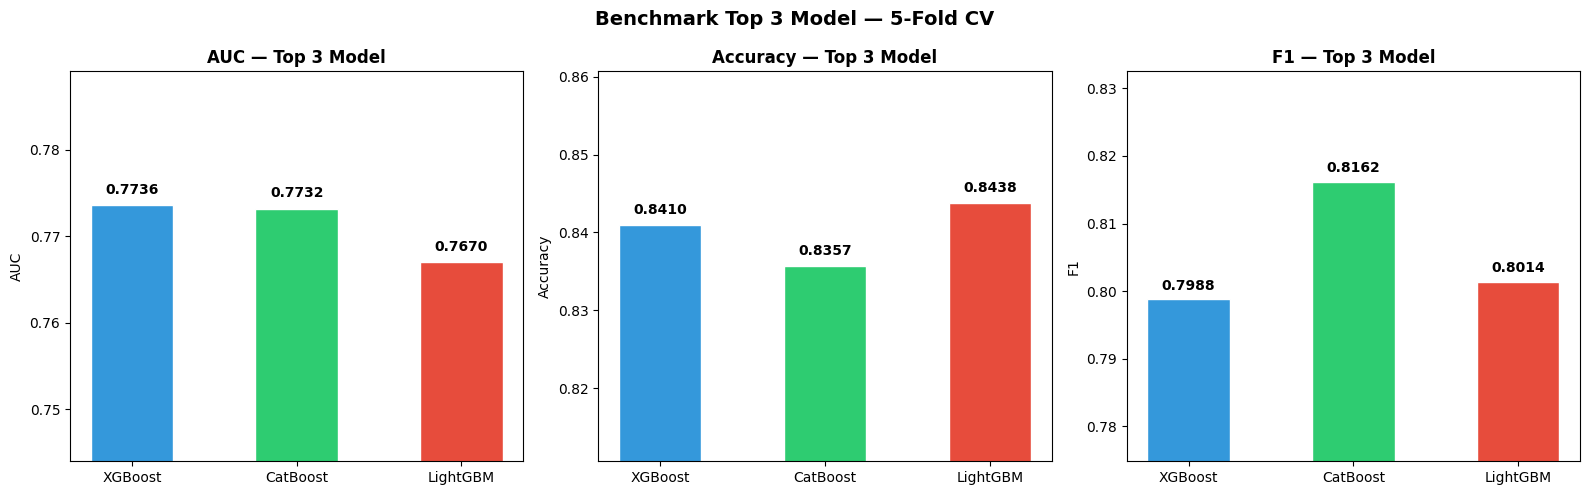

✅ Plot tersimpan: top3_benchmark.png


In [18]:
# ── Visualisasi perbandingan 3 model ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['AUC', 'Accuracy', 'F1']
colors    = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, width=0.5, edgecolor='white')
    ax.set_ylim(results_df[metric].min() * 0.97, results_df[metric].max() * 1.02)
    ax.set_title(f'{metric} — Top 3 Model', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Benchmark Top 3 Model — 5-Fold CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top3_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot tersimpan: top3_benchmark.png')

## 6. Hyperparameter Tuning — Model Terbaik (Optuna)

> Model terpilih = yang AUC tertinggi dari Section 5.  
> Optuna mencari hyperparameter optimal dengan **50 trial**, optimasi AUC 5-Fold CV.

In [19]:
print(f'\n🔍 Mulai tuning: {best_baseline_name}')
print('   50 trials × 5-Fold CV — harap tunggu (~5-15 menit)\n')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────────────────────────────────────
# Objective function untuk masing-masing model
# ─────────────────────────────────────────────────────────────────────────

def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'scale_pos_weight' : scale_pos_w,
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    clf  = LGBMClassifier(**params)
    pipe = Pipeline([
        ('prep', build_preprocessor(num_cols, cat_cols)),
        ('clf',  clf)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_tune,
                            scoring='roc_auc', n_jobs=-1)
    return scores['test_score'].mean()


def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'scale_pos_weight' : scale_pos_w,
        'eval_metric'      : 'auc',
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }
    clf  = XGBClassifier(**params)
    pipe = ImbPipeline([
        ('prep',  build_preprocessor(num_cols, cat_cols)),
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf',   clf)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_tune,
                            scoring='roc_auc', n_jobs=-1)
    return scores['test_score'].mean()


def objective_catboost(trial):
    params = {
        'iterations'        : trial.suggest_int('iterations', 300, 1500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth'             : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'   : trial.suggest_float('random_strength', 0.0, 2.0),
        'auto_class_weights': 'Balanced',
        'random_state'      : 42,
        'verbose'           : 0,
    }
    clf  = CatBoostClassifier(**params)
    pipe = ImbPipeline([
        ('prep',  build_preprocessor(num_cols, cat_cols)),
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf',   clf)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv_tune,
                            scoring='roc_auc', n_jobs=-1)
    return scores['test_score'].mean()


# ── Pilih objective berdasarkan model terbaik ─────────────────────────────
objective_map = {
    'LightGBM': objective_lgbm,
    'XGBoost' : objective_xgb,
    'CatBoost': objective_catboost,
}

study = optuna.create_study(direction='maximize', study_name=f'tune_{best_baseline_name}')
study.optimize(objective_map[best_baseline_name], n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f'\n✅ Tuning selesai!')
print(f'   Best AUC (CV)  : {study.best_value:.4f}')
print(f'   Best params    :')
for k, v in best_params.items():
    print(f'     {k}: {v}')


🔍 Mulai tuning: XGBoost
   50 trials × 5-Fold CV — harap tunggu (~5-15 menit)



  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 12. Best value: 0.783389: 100%|██████████| 50/50 [02:49<00:00,  3.39s/it]


✅ Tuning selesai!
   Best AUC (CV)  : 0.7834
   Best params    :
     n_estimators: 529
     learning_rate: 0.021494686739276486
     max_depth: 5
     min_child_weight: 9
     subsample: 0.8798165933607971
     colsample_bytree: 0.5241726435774776
     reg_alpha: 0.050092076828544455
     reg_lambda: 0.1737598671838755


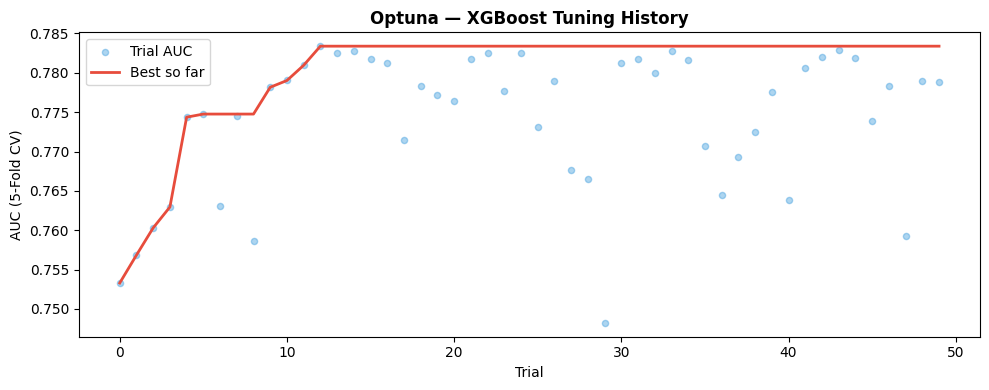

✅ Plot tersimpan: optuna_history.png


In [20]:
# ── Plot Optuna — Optimization History ───────────────────────────────────
trial_nums = [t.number for t in study.trials]
trial_vals = [t.value  for t in study.trials]
best_so_far = np.maximum.accumulate(trial_vals)

plt.figure(figsize=(10, 4))
plt.scatter(trial_nums, trial_vals, alpha=0.4, color='#3498db', s=20, label='Trial AUC')
plt.plot(trial_nums, best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
plt.xlabel('Trial')
plt.ylabel('AUC (5-Fold CV)')
plt.title(f'Optuna — {best_baseline_name} Tuning History', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot tersimpan: optuna_history.png')

## 7. Train Model Tuned + Threshold Tuning + Evaluasi Final

⏳ Training model tuned (XGBoost) pada 80% data...
✅ Training selesai

⏳ Threshold tuning via OOF...
  Fold 1 selesai
  Fold 2 selesai
  Fold 3 selesai
  Fold 4 selesai
  Fold 5 selesai

  Threshold default (0.50) → Acc = 0.8419
  Threshold optimal (0.69)  → Acc = 0.8461


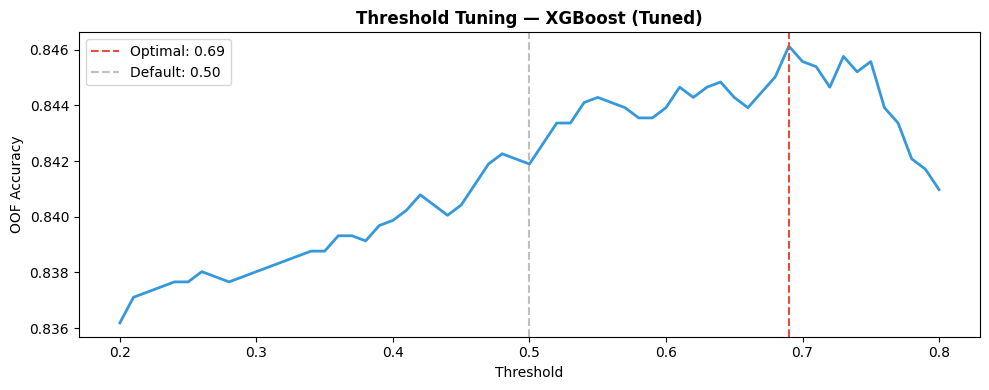

In [22]:
# ── Bangun HANYA model terbaik dengan best_params ────────────────────────
if best_baseline_name == 'LightGBM':
    tuned_clf = LGBMClassifier(
        **best_params,
        scale_pos_weight = scale_pos_w,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1
    )
    use_smote = False

elif best_baseline_name == 'XGBoost':
    tuned_clf = XGBClassifier(
        **best_params,
        scale_pos_weight = scale_pos_w,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0
    )
    use_smote = True

elif best_baseline_name == 'CatBoost':
    tuned_clf = CatBoostClassifier(
        **best_params,
        auto_class_weights = 'Balanced',
        random_state       = 42,
        verbose            = 0
    )
    use_smote = True

# ── Pipeline sesuai model ─────────────────────────────────────────────────
if use_smote:
    pipe_tuned = ImbPipeline([
        ('prep',  build_preprocessor(num_cols, cat_cols)),
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('clf',   tuned_clf)
    ])
else:
    pipe_tuned = Pipeline([
        ('prep', build_preprocessor(num_cols, cat_cols)),
        ('clf',  tuned_clf)
    ])

print(f'⏳ Training model tuned ({best_baseline_name}) pada 80% data...')
pipe_tuned.fit(X_train, y_train)
print('✅ Training selesai')

# ── OOF Threshold Tuning ─────────────────────────────────────────────────
print('\n⏳ Threshold tuning via OOF...')
oof_proba = np.zeros(len(X_train))

for fold, (tr_idx, val_idx) in enumerate(cv_tune.split(X_train, y_train), 1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    if use_smote:
        fold_pipe = ImbPipeline([
            ('prep',  build_preprocessor(num_cols, cat_cols)),
            ('smote', SMOTE(random_state=42, k_neighbors=5)),
            ('clf',   tuned_clf)
        ])
    else:
        fold_pipe = Pipeline([
            ('prep', build_preprocessor(num_cols, cat_cols)),
            ('clf',  tuned_clf)
        ])

    fold_pipe.fit(Xtr, ytr)
    oof_proba[val_idx] = fold_pipe.predict_proba(Xval)[:, 1]
    print(f'  Fold {fold} selesai')

thresholds   = np.arange(0.20, 0.80, 0.01)
thresh_accs  = [accuracy_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds]
best_thresh  = thresholds[np.argmax(thresh_accs)]
best_acc_oof = max(thresh_accs)

print(f'\n  Threshold default (0.50) → Acc = {accuracy_score(y_train, (oof_proba>=0.50).astype(int)):.4f}')
print(f'  Threshold optimal ({best_thresh:.2f})  → Acc = {best_acc_oof:.4f}')

# Plot threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, thresh_accs, color='#3498db', linewidth=2)
plt.axvline(best_thresh, color='#e74c3c', linestyle='--', label=f'Optimal: {best_thresh:.2f}')
plt.axvline(0.50, color='gray', linestyle='--', alpha=0.5, label='Default: 0.50')
plt.xlabel('Threshold')
plt.ylabel('OOF Accuracy')
plt.title(f'Threshold Tuning — {best_baseline_name} (Tuned)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Evaluasi Final pada Holdout 20% ──────────────────────────────────────
y_proba_test = pipe_tuned.predict_proba(X_test)[:, 1]
y_pred_def   = (y_proba_test >= 0.50).astype(int)
y_pred_opt   = (y_proba_test >= best_thresh).astype(int)

print('\n' + '=' * 70)
print(f'📊 EVALUASI FINAL — {best_baseline_name} TUNED (holdout 20%)')
print('=' * 70)
print(f"{'Metric':<12} {'Threshold 0.50':>15} {'Threshold ' + str(round(best_thresh,2)):>16}")
print('-' * 45)

metrics_fn = [
    ('Accuracy',  lambda yt, yp: accuracy_score(yt, yp)),
    ('AUC',       lambda yt, yp: roc_auc_score(yt, y_proba_test)),
    ('F1',        lambda yt, yp: f1_score(yt, yp, average='weighted')),
    ('Precision', lambda yt, yp: precision_score(yt, yp, average='weighted', zero_division=0)),
    ('Recall',    lambda yt, yp: recall_score(yt, yp, average='weighted')),
]

final_scores = {}
for metric, fn in metrics_fn:
    v_def = fn(y_test, y_pred_def)
    v_opt = fn(y_test, y_pred_opt)
    gain  = v_opt - v_def
    final_scores[metric] = v_opt
    print(f'  {metric:<10} {v_def:>15.4f} {v_opt:>15.4f}  ({gain:+.4f})')

# ── Perbandingan: Baseline vs Tuned ──────────────────────────────────────
baseline_row = results_df[results_df['Model'] == best_baseline_name].iloc[0]

print('\n' + '=' * 70)
print('📈 PERBANDINGAN: Baseline vs Tuned')
print('=' * 70)
print(f"{'Metric':<12} {'Baseline (CV)':>15} {'Tuned (Holdout)':>16} {'Delta':>8}")
print('-' * 55)
for metric in ['Accuracy', 'AUC', 'F1']:
    base_val  = baseline_row[metric]
    tuned_val = final_scores[metric]
    delta     = tuned_val - base_val
    status    = '✅' if delta > 0 else '❌'
    print(f'  {metric:<10} {base_val:>15.4f} {tuned_val:>15.4f}  {delta:>+7.4f}  {status}')

# ── PyCaret Comparison ────────────────────────────────────────────────────
pycaret = {'Accuracy': 0.8395, 'AUC': 0.7925, 'F1': 0.9082, 'Recall': 0.9519}
print('\n' + '=' * 70)
print('📈 vs PyCaret LightGBM (benchmark asal)')
print('=' * 70)
for metric, ref in pycaret.items():
    ours   = final_scores.get(metric, None)
    if ours:
        diff   = ours - ref
        status = '✅ LEBIH TINGGI' if diff > 0 else '❌ masih di bawah'
        print(f'  {metric:<10}: PyCaret={ref:.4f}  Tuned={ours:.4f}  Δ={diff:+.4f}  {status}')


📊 EVALUASI FINAL — XGBoost TUNED (holdout 20%)
Metric        Threshold 0.50   Threshold 0.69
---------------------------------------------
  Accuracy            0.8447          0.8352  (-0.0096)
  AUC                 0.7945          0.7945  (+0.0000)
  F1                  0.7991          0.8062  (+0.0070)
  Precision           0.8185          0.8012  (-0.0172)
  Recall              0.8447          0.8352  (-0.0096)

📈 PERBANDINGAN: Baseline vs Tuned
Metric         Baseline (CV)  Tuned (Holdout)    Delta
-------------------------------------------------------
  Accuracy            0.8410          0.8352  -0.0058  ❌
  AUC                 0.7736          0.7945  +0.0209  ✅
  F1                  0.7988          0.8062  +0.0074  ✅

📈 vs PyCaret LightGBM (benchmark asal)
  Accuracy  : PyCaret=0.8395  Tuned=0.8352  Δ=-0.0043  ❌ masih di bawah
  AUC       : PyCaret=0.7925  Tuned=0.7945  Δ=+0.0020  ✅ LEBIH TINGGI
  F1        : PyCaret=0.9082  Tuned=0.8062  Δ=-0.1020  ❌ masih di bawah
  Recall 

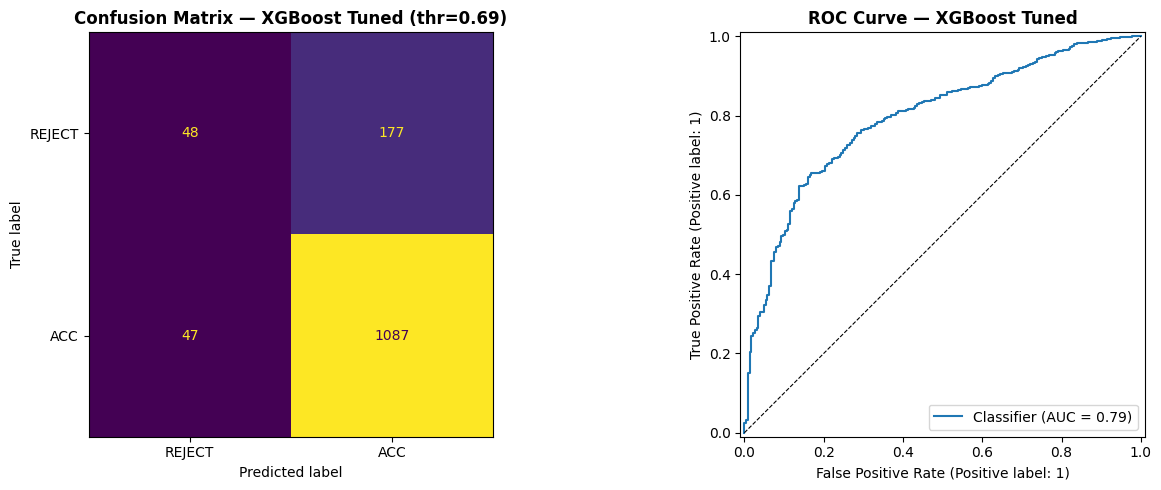

✅ Plot tersimpan: final_eval_tuned.png


In [24]:
# ── Confusion Matrix + ROC Curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=['REJECT', 'ACC'],
    colorbar=False, ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_baseline_name} Tuned (thr={best_thresh:.2f})',
                  fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].set_title(f'ROC Curve — {best_baseline_name} Tuned', fontweight='bold')

plt.tight_layout()
plt.savefig('final_eval_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot tersimpan: final_eval_tuned.png')

## 8. Simpan Model Final

In [25]:
joblib.dump(pipe_tuned,    'model_tuned_final.pkl')
joblib.dump(best_thresh,   'threshold_tuned.pkl')
joblib.dump(selected_clf,  'selected_features.pkl')
joblib.dump(best_params,   'best_params.pkl')

print('✅ Semua file tersimpan:')
print(f'   model_tuned_final.pkl   → pipeline model ({best_baseline_name} tuned)')
print(f'   threshold_tuned.pkl     → threshold optimal ({best_thresh:.2f})')
print(f'   selected_features.pkl   → {len(selected_clf)} fitur terpilih')
print(f'   best_params.pkl         → hyperparameter terbaik Optuna')

✅ Semua file tersimpan:
   model_tuned_final.pkl   → pipeline model (XGBoost tuned)
   threshold_tuned.pkl     → threshold optimal (0.69)
   selected_features.pkl   → 26 fitur terpilih
   best_params.pkl         → hyperparameter terbaik Optuna
